# Подготовка данных

Кратко: ноутбук содержит очистку и фичеризацию


In [1]:
from src.utils import RawCsvReader

df = RawCsvReader().read()

2026-05-24 18:53:00,947 | INFO | logs.logger | Start reading data
2026-05-24 18:53:52,491 | INFO | logs.logger | Shape: (1871372, 280)


Анализ режимов торгов (boardid)

In [2]:
df['boardid'].unique()

array(['TQBR', 'TQPI', 'SMAL', 'EQDP', 'TQDE', 'EQNE', 'EQBS', 'EQLI',
       'EQNL', 'EQBR', 'EQLV', 'TQNL', 'EQDE', 'TQNE', 'TQBS', 'SPEQ',
       'EQCC', 'TQLV', 'TQDP'], dtype=object)

	•	TQBR — акции, основной стакан (T+2)
	•	TQBS — акции, T+ режим (вариация расчётов, реже используется)
	•	TQPI — режим для квалифицированных инвесторов
	•	TQDE — депозитарные расписки
	•	TQDP — DR / спецрежим
	•	TQNE — адресные сделки в T+
	•	TQLV — низколиквидные бумаги
	•	TQNL — неликвид / ограниченный режим
	•	EQBR — акции (аналог TQBR, но менее ликвидный)
	•	EQNE — адресные сделки
	•	EQBS — режим расчётов
	•	EQLI — листинг / малоликвидные
	•	EQNL — неликвид
	•	EQLV — low volume
	•	EQDE — депозитарные расписки
	•	EQDP — DR / спецрежим
	•	EQCC — клиринговый / спецрежим
	•	SMAL — неполные лоты (odd lots)
	•	SPEQ — negotiated / специальные сделки

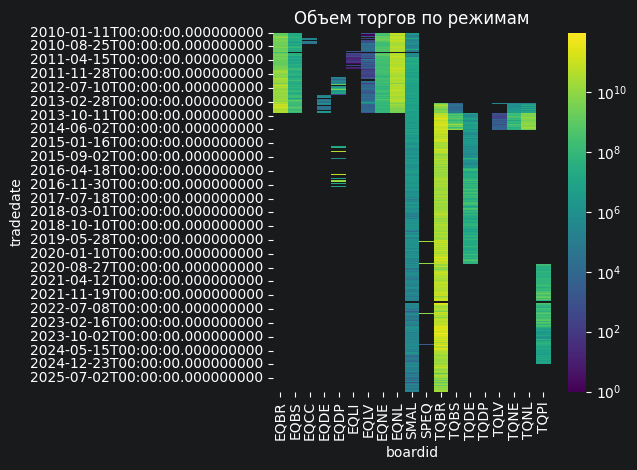

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def plot_board_volume_heatmap(df, title):
    pivot = df.pivot_table(index='tradedate', columns='boardid', values='volume', aggfunc='sum')
    sns.heatmap(pivot, cmap="viridis", norm=LogNorm())
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_board_volume_heatmap(df, "Объем торгов по режимам")

### Предобработка (sklearn pipeline)

In [4]:
from src import (
    build_data_processing_pipeline,
    build_feature_engineering_pipeline,
)

data_processing_pipeline = build_data_processing_pipeline()
feature_engineering_pipeline = build_feature_engineering_pipeline()

df = data_processing_pipeline.fit_transform(df)
df = feature_engineering_pipeline.fit_transform(df)

2026-05-24 18:53:57,979 | INFO | logs.logger | Step filter_boards finished. Shape: ((960151, 280))
/Users/alexander/PycharmProjects/vmk_thesis/src/data_processing.py:24: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["base_secid"] = df[secid].str.replace(rf"{template}", "", regex=True)
2026-05-24 18:54:06,726 | INFO | logs.logger | Step drop_additional_issues finished. Shape: ((960151, 286))
2026-05-24 18:54:09,245 | INFO | logs.logger | Step filter_null_cols finished. Shape: ((906363, 286))
2026-05-24 18:54:09,390 | INFO | logs.logger | Step categorize finished. Shape: ((906363, 286))
/Users/alexander/PycharmProjects/vmk_thesis/src/data_processing.py:68: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is d

Save processed data

In [5]:
from utils import save_processed_csv, processed_dataset_name
save_processed_csv(df, processed_dataset_name)